# Simple LLM Application

In [ ]:
import getpass
import os
from dotenv import load_dotenv
load_dotenv()

if not os.environ.get("OPENAI_API_KEY"):
  os.environ["OPENAI_API_KEY"] = getpass.getpass("Enter API key for OpenAI: ")

from langchain.chat_models import init_chat_model

model = init_chat_model("gpt-4o-mini", model_provider="openai")

In [2]:
from langchain_core.messages import HumanMessage, SystemMessage

messages = [
    SystemMessage(content="Translate the following from English into Italian"),
    HumanMessage(content="I love software development!"),
]

model.invoke(messages)

AIMessage(content='Amo lo sviluppo software!', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 6, 'prompt_tokens': 23, 'total_tokens': 29, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_560af6e559', 'id': 'chatcmpl-CPTZegHtuG5pc5dqCqUrEzdaugI1B', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--dfb15d34-66bb-4ff6-bee8-cebccbeaea0d-0', usage_metadata={'input_tokens': 23, 'output_tokens': 6, 'total_tokens': 29, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [3]:
from langchain_core.prompts import ChatPromptTemplate

system_template = "Translate the following from English into {language}"

prompt_template = ChatPromptTemplate.from_messages(
    [("system", system_template), ("user", "{text}")]
)

In [4]:
prompt = prompt_template.invoke({"language": "Igbo", "text": "hi!"})

prompt

ChatPromptValue(messages=[SystemMessage(content='Translate the following from English into Igbo', additional_kwargs={}, response_metadata={}), HumanMessage(content='hi!', additional_kwargs={}, response_metadata={})])

In [5]:
response = model.invoke(prompt)
print(response.content)

Ndewo!


# First Data Visualization

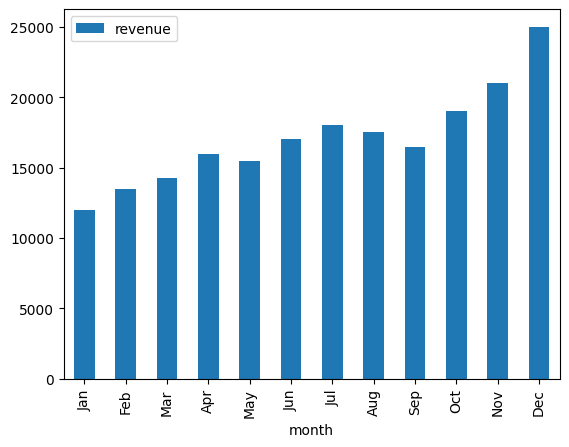

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv('sales.csv')
data.plot(kind='bar', x='month', y='revenue')
plt.show()


# Chatbot

In [19]:
import getpass
import os
from dotenv import load_dotenv
load_dotenv()

if not os.environ.get("OPENAI_API_KEY"):
  os.environ["OPENAI_API_KEY"] = getpass.getpass("Enter API key for OpenAI: ")

from langchain.chat_models import init_chat_model

model = init_chat_model(os.environ.get("MODEL_NAME"), model_provider="openai")

In [6]:
from langchain_core.messages import HumanMessage, AIMessage

model.invoke(
    [
        HumanMessage(content="Hi! I'm Chiemela"),
        AIMessage(content="Hello Chiemela! How can I assist you today?"),
        HumanMessage(content="What's my name?"),
    ]
)

AIMessage(content='Your name is Chiemela. How can I help you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 87, 'prompt_tokens': 38, 'total_tokens': 125, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 64, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-CPTrZtIDmoj6EbHp87nVLtZJHJI8A', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--eab3ef4d-99ca-49bf-9154-366b7c16ba8b-0', usage_metadata={'input_tokens': 38, 'output_tokens': 87, 'total_tokens': 125, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 64}})

Message persistence

In [25]:
from typing import Sequence

from langchain_core.messages import BaseMessage
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import START, StateGraph, add_messages
from typing_extensions import Annotated, TypedDict


class State(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]
    language: str



# Define a new graph
workflow = StateGraph(state_schema=State)


# Define the function that calls the model
def call_model(state: State):
    prompt = prompt_template.invoke(state)
    response = model.invoke(prompt)
    return {"messages": response}


# Define the (single) node in the graph
workflow.add_edge(START, "model")
workflow.add_node("model", call_model)

# Add memory
memory = MemorySaver()
app = workflow.compile(checkpointer=memory)

In [9]:
config = {"configurable": {"thread_id": "abc123"}}
query = "Hi! I'm Chiemela."

input_messages = [HumanMessage(query)]
output = app.invoke({"messages": input_messages}, config)
output["messages"][-1].pretty_print()  # output contains all messages in state

================================== Ai Message ==================================

Hi Chiemela — nice to meet you! How can I help today? (If you’d like, tell me your pronouns or how you prefer to be addressed.)


In [15]:
# config = {"configurable": {"thread_id": "abc456"}}
query = "What's my name?"

input_messages = [HumanMessage(query)]
output = app.invoke({"messages": input_messages}, config)
output["messages"][-1].pretty_print()

================================== Ai Message ==================================

Your name is Chiemela.


Prompt Templating

In [24]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

prompt_template = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a helpful assistant. Answer all questions to the best of your ability in {language}.",
        ),
        MessagesPlaceholder(variable_name="messages"),
    ]
)

In [21]:
config = {"configurable": {"thread_id": "abc345"}}
query = "Hi! I'm Fisher."

input_messages = [HumanMessage(query)]
output = app.invoke({"messages": input_messages}, config)
output["messages"][-1].pretty_print()

================================== Ai Message ==================================

Ahoy, Fisher! Pleasure t' meet ye, matey. What can this ol' sea dog do fer ye today?


In [22]:
query = "What is my name?"

input_messages = [HumanMessage(query)]
output = app.invoke({"messages": input_messages}, config)
output["messages"][-1].pretty_print()

================================== Ai Message ==================================

Yer name be Fisher, matey. What can this ol' sea dog do fer ye next?


In [27]:
config = {"configurable": {"thread_id": "abc456"}}
query = "Hi! I'm Barry Allen."
language = "Nigerian Pigin English"

input_messages = [HumanMessage(query)]
output = app.invoke(
    {"messages": input_messages, "language": language},
    config,
)
output["messages"][-1].pretty_print()

================================== Ai Message ==================================

Hi Barry Allen! How you dey? Wetin I fit help you with today?


In [29]:
query = "Tell me a good weekend joke?"

input_messages = [HumanMessage(query)]
output = app.invoke(
    {"messages": input_messages},
    config,
)
output["messages"][-1].pretty_print()

================================== Ai Message ==================================

Alright Barry — here some weekend jokes for you:

1) I promise say I go wake up early this weekend. Alarm wake me, I tell am “abeg, try relax.” Alarm kon say “na you try small!”  

2) Person tell friend: “I go start diet this weekend.” Weekend finish, e still dey chop. Friend ask why. E say: “I dey do research—Monday na the serious plan.”  

3) Why Saturday and Sunday good friends? Because together dem dey make Monday slow on entrance.  

Which one make you laugh pass?
